<a href="https://colab.research.google.com/github/Dawood-Ali123/Pytorch_learning/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd

In [40]:
df=pd.read_excel('/content/100_Unique_QA_Dataset.xlsx')
display(df.head())

,question,answer
0,What is the capital of France?,Paris
1,What is the capital of Germany?,Berlin
2,Who wrote 'To Kill a Mockingbird'?,Harper-Lee
3,What is the largest planet in our solar system?,Jupiter
4,What is the boiling point of water in Celsius?,100


In [41]:
#first wetokenize our data
def tokenize(text):
  # Ensure text is a string before performing string operations
  text = str(text)
  text=text.lower()
  text=text.replace('?','')
  text=text.replace("'",'')
  return text.split()

In [42]:
vocab={'<UNK>':0}
def build_vocab(row):
  #print(row['question'],row['answer'])
  tokenized_question=tokenize(row['question'])
  tokenized_answer=tokenize(row['answer'])
  merged_tokens=tokenized_question+tokenized_answer
  for token in merged_tokens:
    if token not in vocab:
      vocab[token]=len(vocab)

  print(merged_tokens)

In [43]:
df.apply(build_vocab,axis=1)

['what', 'is', 'the', 'capital', 'of', 'france', 'paris']
['what', 'is', 'the', 'capital', 'of', 'germany', 'berlin']
['who', 'wrote', 'to', 'kill', 'a', 'mockingbird', 'harper-lee']
['what', 'is', 'the', 'largest', 'planet', 'in', 'our', 'solar', 'system', 'jupiter']
['what', 'is', 'the', 'boiling', 'point', 'of', 'water', 'in', 'celsius', '100']
['who', 'painted', 'the', 'mona', 'lisa', 'leonardo-da-vinci']
['what', 'is', 'the', 'square', 'root', 'of', '64', '8']
['what', 'is', 'the', 'chemical', 'symbol', 'for', 'gold', 'au']
['which', 'year', 'did', 'world', 'war', 'ii', 'end', '1945']
['what', 'is', 'the', 'longest', 'river', 'in', 'the', 'world', 'nile']
['what', 'is', 'the', 'capital', 'of', 'japan', 'tokyo']
['who', 'developed', 'the', 'theory', 'of', 'relativity', 'albert-einstein']
['what', 'is', 'the', 'freezing', 'point', 'of', 'water', 'in', 'fahrenheit', '32']
['which', 'planet', 'is', 'known', 'as', 'the', 'red', 'planet', 'mars']
['who', 'is', 'the', 'author', 'of', '19

,0
0,None
1,None
2,None
3,None
4,None
...,...
85,None
86,None
87,None
88,None


In [44]:
len(vocab)

324

In [45]:
vocab

{'<UNK>': 0,
 'what': 1,
 'is': 2,
 'the': 3,
 'capital': 4,
 'of': 5,
 'france': 6,
 'paris': 7,
 'germany': 8,
 'berlin': 9,
 'who': 10,
 'wrote': 11,
 'to': 12,
 'kill': 13,
 'a': 14,
 'mockingbird': 15,
 'harper-lee': 16,
 'largest': 17,
 'planet': 18,
 'in': 19,
 'our': 20,
 'solar': 21,
 'system': 22,
 'jupiter': 23,
 'boiling': 24,
 'point': 25,
 'water': 26,
 'celsius': 27,
 '100': 28,
 'painted': 29,
 'mona': 30,
 'lisa': 31,
 'leonardo-da-vinci': 32,
 'square': 33,
 'root': 34,
 '64': 35,
 '8': 36,
 'chemical': 37,
 'symbol': 38,
 'for': 39,
 'gold': 40,
 'au': 41,
 'which': 42,
 'year': 43,
 'did': 44,
 'world': 45,
 'war': 46,
 'ii': 47,
 'end': 48,
 '1945': 49,
 'longest': 50,
 'river': 51,
 'nile': 52,
 'japan': 53,
 'tokyo': 54,
 'developed': 55,
 'theory': 56,
 'relativity': 57,
 'albert-einstein': 58,
 'freezing': 59,
 'fahrenheit': 60,
 '32': 61,
 'known': 62,
 'as': 63,
 'red': 64,
 'mars': 65,
 'author': 66,
 '1984': 67,
 'george-orwell': 68,
 'currency': 69,
 'unit

In [46]:
def text_to_index(text,vocab):
  indexed_text=[]
  for token in tokenize(text):
    if token in vocab:
      indexed_text.append(vocab[token])
    else:
      indexed_text.append(vocab['<UNK>'])
  return indexed_text


it first convert the text to token and then check word by word in the vocab if this word is presesnt in the vocab retrn the index of that word in the indexd text it not then append the vocab UNK index

In [47]:
text_to_index("My name is dawood",vocab)

[0, 0, 2, 0]

In [48]:
import torch
from torch.utils.data import Dataset,DataLoader

In [49]:
class CustomDataset(Dataset):
  def __init__(self,df,vocab):
    self.df=df
    self.vocab=vocab
  def __len__(self):
    return len(self.df)
  def __getitem__(self,index):
    numerical_question=text_to_index(self.df.iloc[index]['question'],self.vocab)
    numerical_answer=text_to_index(self.df.iloc[index]['answer'],self.vocab)
    return torch.tensor(numerical_question),torch.tensor(numerical_answer)

In [50]:
dataset=CustomDataset(df,vocab)

In [51]:
dataset[30]

(tensor([  1,   2,   3, 122, 123,  19,   3,  45]), tensor([124]))

In [52]:
dataloader=DataLoader(dataset,batch_size=1,shuffle=True)

In [53]:
for question,answer in dataloader:
  print(question,answer[0])

tensor([[ 1,  2,  3, 92, 93, 94]]) tensor([95])
tensor([[78, 79, 80, 81, 82, 83, 84]]) tensor([85])
tensor([[  1,   2,   3,   4,   5, 113]]) tensor([114])
tensor([[ 10, 308,   3, 309, 310]]) tensor([311])
tensor([[42, 86, 87, 88, 89, 39, 90]]) tensor([91])
tensor([[ 78,  79, 150, 151,  14, 152, 153]]) tensor([154])
tensor([[ 42, 200,   2,  14, 201, 202, 203, 204]]) tensor([205])
tensor([[ 1,  2,  3, 69,  5, 53]]) tensor([260])
tensor([[1, 2, 3, 4, 5, 8]]) tensor([9])
tensor([[  1,   2,   3,  69,   5, 155]]) tensor([156])
tensor([[ 42, 263, 264,  14, 265, 266, 158, 267]]) tensor([268])
tensor([[ 42, 216, 118, 217, 218,  19,  14, 219,  43]]) tensor([220])
tensor([[ 1,  2,  3, 37, 38, 39, 40]]) tensor([41])
tensor([[ 1,  2,  3, 33, 34,  5, 35]]) tensor([36])
tensor([[ 42, 290, 291, 118, 292, 158, 293, 294]]) tensor([295])
tensor([[ 42, 137,   2, 138,  39, 175, 269]]) tensor([99])
tensor([[  1,   2,   3,   4,   5, 286]]) tensor([287])
tensor([[ 10, 140,   3, 141, 171,   5,   3,  70, 172]])

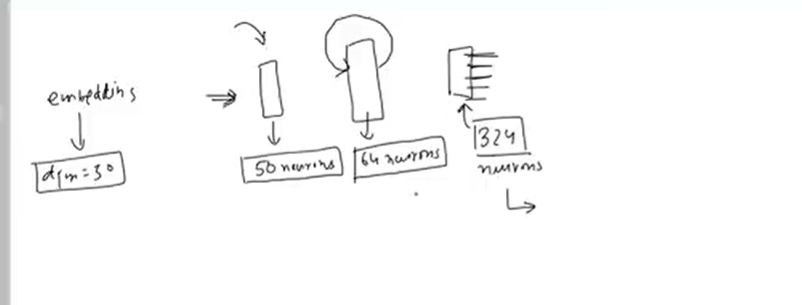

In [54]:
import torch.nn as nn

In [55]:
import torch.nn as nn
# from numpy._core.fromnumeric import squeeze # This import is not needed for torch.Tensor.squeeze
class SimpleRNN(nn.Module):
  def __init__(self,vocab_size):
    super().__init__()
    self.embedding=nn.Embedding(vocab_size,embedding_dim=50)
    #it concert every word to the 50 dimesion
    self.rnn=nn.RNN(50,64,batch_first=True)
    self.fc=nn.Linear(64,vocab_size)
  def forward(self,x):
    embeded_question=self.embedding(x)
    hidden,final=self.rnn(embeded_question) # _output is the full sequence output, final is the last hidden state (hn)
    # final has shape (num_layers * num_directions, batch_size, hidden_size)
    # Assuming single layer, single direction RNN, final is (1, batch_size, hidden_size)
    # We need (batch_size, hidden_size) for the linear layer
    output=self.fc(final.squeeze(0)) # Corrected: use .squeeze(0) on the tensor
    return output

Here we cannot use the the nn.sequentail beacuse it forward only one input but here nn.RNN give the 2 input so here we cannot use this

In [56]:
learning_rate=0.001
epoches=20
model=SimpleRNN(len(vocab))
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [57]:
for epoch in range(epoches):
  total_loss=0
  for question,answer in dataloader:
    optimizer.zero_grad()
    output=model(question)
    # CrossEntropyLoss expects input (N, C) and target (N) of type long for class indices
    # 'answer' from dataloader for a single token answer usually has shape (batch_size, 1)
    # so we squeeze it to (batch_size) to match the target shape expectation
    # Ensure target is long type for class indices
    loss=criterion(output, answer[0])
    loss.backward()
    optimizer.step()
    total_loss=total_loss+loss.item()
  print(f"Epoch {epoch+1},Loss :{total_loss:4f}")

Epoch 1,Loss :523.537644
Epoch 2,Loss :450.190527
Epoch 3,Loss :370.096004
Epoch 4,Loss :311.880702
Epoch 5,Loss :261.767040
Epoch 6,Loss :215.547655
Epoch 7,Loss :171.837106
Epoch 8,Loss :134.285609
Epoch 9,Loss :103.311647
Epoch 10,Loss :78.918694
Epoch 11,Loss :60.943833
Epoch 12,Loss :47.512057
Epoch 13,Loss :37.804750
Epoch 14,Loss :30.886643
Epoch 15,Loss :25.709399
Epoch 16,Loss :21.541810
Epoch 17,Loss :18.499353
Epoch 18,Loss :15.677361
Epoch 19,Loss :13.568110
Epoch 20,Loss :11.757340


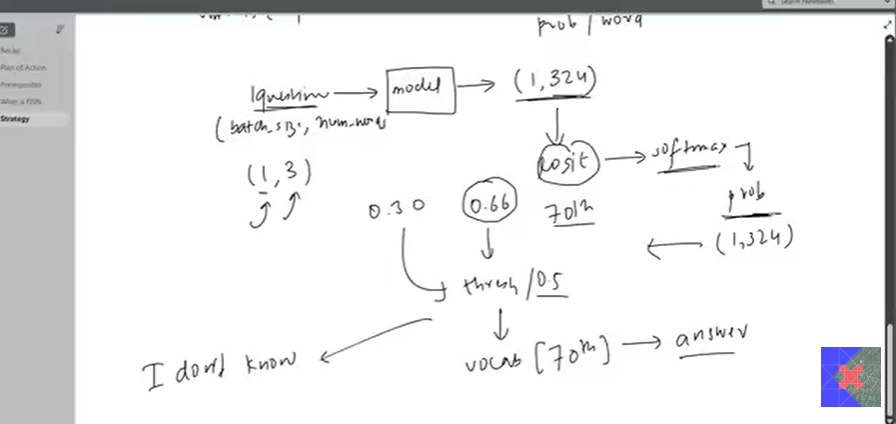

In [64]:
def predict(model,question,thershold=0.5):
  numerical_question=text_to_index(question ,vocab)
  print(numerical_question)
  output=model(torch.tensor(numerical_question)).unsqueeze(0)
  print(output)
  #convert logits to the probs
  probs=torch.nn.functional.softmax(output,dim=1)
  #find the max probability
  value,index=torch.max(probs,dim=1)
  print(value ,index)
  if value<thershold:
    print("i dont know")
  else:
    print(list(vocab.keys())[index])


In [65]:
predict(model,"what is the largest planet in our solar system")

[1, 2, 3, 17, 18, 19, 20, 21, 22]
tensor([[-3.5063, -3.3974, -4.5022, -3.3560, -3.4541, -3.5046,  0.0578, -2.5204,
         -3.4788, -1.5188, -3.4215, -3.4670, -3.3258, -3.6473, -3.3350, -3.6191,
          0.5290, -3.4270, -3.6550, -3.5727, -3.6499, -3.1231, -3.4750,  6.8955,
         -3.8180, -3.8775, -3.9402, -3.4742,  1.8213, -3.0966, -3.3659, -3.7291,
         -1.4183, -3.6948, -3.8461, -3.4748,  3.7544, -3.5699, -3.9309, -3.3144,
         -4.0151, -0.2341, -3.9287, -3.6086, -3.6206, -3.5717, -3.6330, -3.8196,
         -3.7132, -0.1979, -3.8930, -3.8474, -0.1908, -1.4734, -2.8598, -3.6084,
         -3.5708, -2.9182, -2.2137, -3.5953, -3.3350, -0.2292, -3.8214, -3.6270,
         -3.6277, -0.8157, -3.2095, -3.9112, -0.9120, -3.9872, -3.2939, -3.6126,
         -0.8885, -3.9127, -1.3415, -3.8112, -3.7906, -2.2724, -3.8283, -3.8444,
         -3.7081, -3.5166, -3.7646, -3.8700, -3.8455,  1.7103, -3.3083, -3.4859,
         -3.4757, -3.2195, -3.8567,  1.2623, -3.4619, -3.3306, -3.5182, -0.